In [26]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import re
import json
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [27]:
# ============================================================
# CELL 2 — LOAD CLEAN DATASET
# ============================================================

DATASET_PATH = "../parquet_exports/retrieval_dataset_clean.parquet"

df = pd.read_parquet(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)

print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET LOADED
Rows    : 228,561
Columns : 14


,similarity_pk,ticket_pk,source_system,text_source_type,similarity_method,retrieval_text_clean,corpus_quality_score,similarity_confidence,priority_encoded,urgency_encoded,impact_encoded,text_word_count,text_char_count,repetition_ratio
0,abf40a28ecf0e6c557ae214fb08e74ca,18ecc0b10c975e6a301035cfacf70a70,customer_support_tickets_200k,real_text,nlp_embedding,the payment was deducted from my bank account ...,1.0,0.9,NaN,NaN,NaN,26,159,0.538462
1,bb988e6a04ac835153c4b6cf016f29a8,c00c291d337d61a00615ab907353bc89,customer_support_tickets_200k,real_text,nlp_embedding,i found a bug in the latest update affecting r...,1.0,0.9,NaN,NaN,NaN,22,127,0.500000
2,d111e697dee69897b9c32be8e0832860,b2e3cefec6c77072e59e9aca6a525670,customer_support_tickets_200k,real_text,nlp_embedding,the application crashes whenever i try to uplo...,1.0,0.9,NaN,NaN,NaN,20,113,0.500000
3,62e2c2f208996587aa73c7b6c2756595,9d0370f2cab75492f184db82f51c103f,customer_support_tickets_200k,real_text,nlp_embedding,my subscription was cancelled without my reque...,1.0,0.9,NaN,NaN,NaN,22,149,0.545455
4,231e0b16e61ae075aed6bcb6e76958f7,ff258a55725d78aa9fac5bdeb364d48b,customer_support_tickets_200k,real_text,nlp_embedding,the system is not syncing data across devices ...,1.0,0.9,NaN,NaN,NaN,18,111,0.500000


In [28]:
# ============================================================
# CELL 3 — BASIC TEXT FEATURES
# ============================================================

TEXT_COLUMN = "retrieval_text_clean"

# Average word length
df["avg_word_length"] = (
    df[TEXT_COLUMN]
    .apply(
        lambda x: np.mean(
            [len(word) for word in str(x).split()]
        ) if str(x).split() else 0
    )
)

In [29]:
# Unique word ratio
df["unique_word_ratio"] = (
    df[TEXT_COLUMN]
    .apply(
        lambda x: (
            len(set(str(x).split())) / len(str(x).split())
        ) if str(x).split() else 0
    )
)

print("Basic NLP features created.")

df[
    [
        "avg_word_length",
        "unique_word_ratio"
    ]
].head()

Basic NLP features created.


,avg_word_length,unique_word_ratio
0,5.153846,0.461538
1,4.818182,0.500000
2,4.700000,0.500000
3,5.818182,0.454545
4,5.222222,0.500000


In [30]:
# ============================================================
# CELL 4 — UPPERCASE RATIO
# ============================================================

def uppercase_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    uppercase_chars = sum(1 for c in text if c.isupper())

    return uppercase_chars / len(text)


df["uppercase_ratio"] = (
    df[TEXT_COLUMN]
    .apply(uppercase_ratio)
)

print("uppercase_ratio created.")

uppercase_ratio created.


In [31]:
# ============================================================
# CELL 5 — DIGIT RATIO
# ============================================================

def digit_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    digits = sum(1 for c in text if c.isdigit())

    return digits / len(text)


df["digit_ratio"] = (
    df[TEXT_COLUMN]
    .apply(digit_ratio)
)

print("digit_ratio created.")

digit_ratio created.


In [32]:
# ============================================================
# CELL 6 — SPECIAL CHARACTER RATIO
# ============================================================

def special_char_ratio(text: str) -> float:

    text = str(text)

    if len(text) == 0:
        return 0.0

    special_chars = len(
        re.findall(r"[^a-zA-Z0-9\s]", text)
    )

    return special_chars / len(text)

df["special_char_ratio"] = (
    df[TEXT_COLUMN]
    .apply(special_char_ratio)
)

print("special_char_ratio created.")

special_char_ratio created.


In [33]:
# ============================================================
# CELL 7 — SOURCE SYSTEM ENCODING
# ============================================================

if "source_system" in df.columns:

    encoder = LabelEncoder()

    df["source_system_encoded"] = (
        encoder.fit_transform(
            df["source_system"].astype(str)
        )
    )

    print("source_system encoded successfully.")

    encoding_mapping = dict(
        zip(
            encoder.classes_,
            encoder.transform(encoder.classes_)
        )
    )

    print("\nEncoding Mapping:")
    print(encoding_mapping)


source_system encoded successfully.

Encoding Mapping:
{'customer_support_tickets_200k': np.int64(0), 'dataset_tickets_multi_lang': np.int64(1)}


In [34]:
# ============================================================
# CELL 8 — SIMILARITY METHOD ENCODING
# ============================================================

if "similarity_method" in df.columns:

    similarity_encoder = LabelEncoder()

    df["similarity_method_encoded"] = (
        similarity_encoder.fit_transform(
            df["similarity_method"].astype(str)
        )
    )

    print("similarity_method encoded successfully.")

similarity_method encoded successfully.


In [35]:
# ============================================================
# CELL 9 — TEXT COMPLEXITY SCORE
# ============================================================

# heuristic feature

df["text_complexity_score"] = (
    (
        df["avg_word_length"] * 0.4
    )
    +
    (
        df["unique_word_ratio"] * 0.4
    )
    +
    (
        df["text_word_count"] / 100 * 0.2
    )
)

print("text_complexity_score created.")

text_complexity_score created.


In [36]:
# ============================================================
# CELL 10 — RETRIEVAL QUALITY SCORE
# ============================================================

quality_columns = [
    c for c in [
        "corpus_quality_score",
        "similarity_confidence",
        "unique_word_ratio"
    ]
    if c in df.columns
]

df["retrieval_quality_score"] = (
    df[quality_columns]
    .fillna(0)
    .mean(axis=1)
)

print("retrieval_quality_score created.")

retrieval_quality_score created.


In [37]:
# ============================================================
# CELL 11 — BUILD DOCUMENT IDS
# ============================================================

df["document_id"] = (
    "doc_" + df.index.astype(str)
)

print("document_id created.")

document_id created.


In [38]:
# ============================================================
# CELL 12 — BUILD METADATA JSON
# ============================================================

METADATA_COLUMNS = [
    c for c in [
        "ticket_pk",
        "source_system",
        "priority_encoded",
        "urgency_encoded",
        "impact_encoded",
        "similarity_method",
        "corpus_quality_score",
        "similarity_confidence"
    ]
    if c in df.columns
]
def build_metadata(row):

    metadata = {}

    for col in METADATA_COLUMNS:
        metadata[col] = row[col]

    return json.dumps(metadata)


df["metadata_json"] = (
    df.apply(build_metadata, axis=1)
)

print("metadata_json created.")


metadata_json created.


In [39]:
# ============================================================
# CELL 13 — FEATURE DISTRIBUTION SUMMARY
# ============================================================

FEATURE_COLUMNS = [
    "avg_word_length",
    "unique_word_ratio",
    "uppercase_ratio",
    "digit_ratio",
    "special_char_ratio",
    "text_complexity_score",
    "retrieval_quality_score"
]

feature_summary = (
    df[FEATURE_COLUMNS]
    .describe()
)

print("=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)

display(feature_summary)

FEATURE SUMMARY


,avg_word_length,unique_word_ratio,uppercase_ratio,digit_ratio,special_char_ratio,text_complexity_score,retrieval_quality_score
count,228561.000000,228561.000000,228561.0,228561.000000,228561.000000,228561.000000,228561.000000
mean,5.230629,0.533096,0.0,0.000125,0.015898,2.359167,0.811032
std,0.677523,0.114311,0.0,0.001466,0.005055,0.308179,0.038104
min,3.666667,0.454545,0.0,0.000000,0.000000,1.775176,0.784848
25%,4.700000,0.500000,0.0,0.000000,0.013423,2.120000,0.800000
50%,5.153846,0.500000,0.0,0.000000,0.015038,2.298154,0.800000
75%,5.818182,0.500000,0.0,0.000000,0.018018,2.553091,0.800000
max,22.791667,1.000000,0.0,0.064516,0.054545,9.564667,0.966667


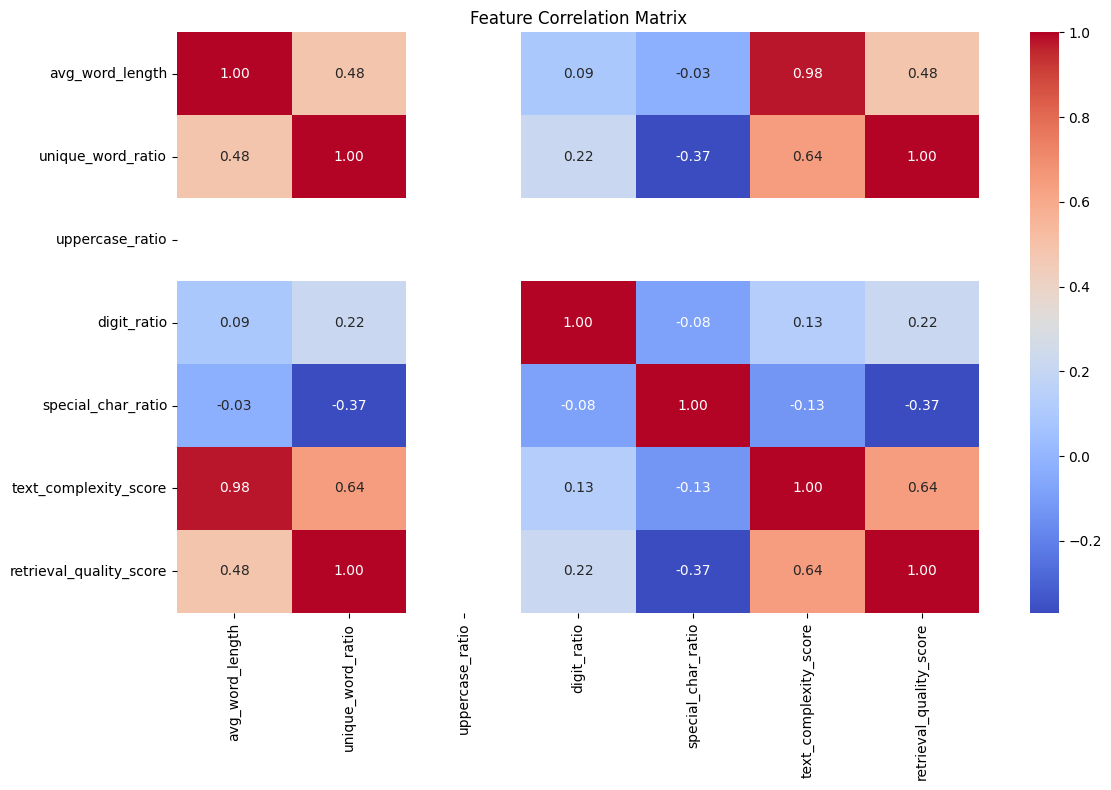

In [40]:
# ============================================================
# CELL 14 — FEATURE CORRELATION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

corr = df[FEATURE_COLUMNS].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# CELL 15 — TOP COMPLEX TICKETS
# ============================================================

top_complex = (
    df.sort_values(
        by="text_complexity_score",
        ascending=False
    )
    .head(10)
)

print("=" * 60)
print("TOP COMPLEX TICKETS")
print("=" * 60)

display(
    top_complex[
        [
            "ticket_pk",
            "text_complexity_score",
            "retrieval_text_clean"
        ]
    ]
)

TOP COMPLEX TICKETS


,ticket_pk,text_complexity_score,retrieval_text_clean
221260,08586bac41d468796d16464948b8d375,9.564667,istcstdintemicrosoftteams synchronisationvonpr...
227620,76c4c9fce94835b95a6c1caf4194d641,5.716000,fakturierungs-unstimmigkeiten das unternehmen ...
227957,ac6d8297676bbac5d460c47cc2a91427,5.484667,marketing-agentur widerspruch support beobacht...
228540,369c1cb7ff9b7ad0a9659c0d2f32b7a2,5.403818,berichtsgenerierungs-system fehlermeldung fina...
213994,49ecbc9cd0952058be6a2fef959c48cd,5.395778,verbessern von investment-analyse-tools optimi...
217690,0cf97e44679273c7367dcf8c96fc2073,5.380000,datensperre bei gesundheitsdienstleistern gesu...
226482,9e32b2d7dfb1daaeeb48222ddfe5bb76,5.278667,aktualisieren der datenanalyse-tools zur verbe...
218974,4c7098dc283d771964421f012698a075,5.266000,finanzanalyse-plattform dienststellungen beein...
226555,5d259eca12d4ed6ab52e1d717c7d70d4,5.228000,datensperrungsverfahren bei gesundheitsdienstl...
210374,10564bf6f8ac2f3df0766a18d856b2da,5.216000,fehler bei investment-optimierung getreten heu...


In [42]:
# ============================================================
# CELL 16 — TOP RETRIEVAL QUALITY TICKETS
# ============================================================

top_quality = (
    df.sort_values(
        by="retrieval_quality_score",
        ascending=False
    )
    .head(10)
)

print("=" * 60)
print("TOP RETRIEVAL QUALITY TICKETS")
print("=" * 60)

display(
    top_quality[
        [
            "ticket_pk",
            "retrieval_quality_score",
            "retrieval_text_clean"
        ]
    ]
)

TOP RETRIEVAL QUALITY TICKETS


,ticket_pk,retrieval_quality_score,retrieval_text_clean
220204,697f5c770d06acea9688d497df6683b3,0.966667,probleme mit ungenauen datenberichten in der a...
228038,33696b357d5d18111e69a1b97bc4a3e5,0.966667,kindly improve security protocols for medical ...
215612,0b0fc8e62c134d787205d94d6b4a538b,0.966667,support for drop an unexpected decline in enga...
228288,a34896b755f4dd5b49ba3ba8841d1098,0.966667,netgear nighthawk mesh wi-fi 6 system details ...
202734,029b6b8057adb39cbed2ddf11404c621,0.966667,festgestellte probleme bei systemaktualisierun...
217353,c36e1cf0c75f1d66f7ce062f4b53ce2b,0.966667,attention needed for a data breach identified ...
213358,60bf5cd18912ebdba44b1b6a83b09b1d,0.966667,improve digital tactics require immediate tech...
220973,2666b6029207615c32d961de855a4002,0.966667,bericht ber abst rzende software bitte helfen sie
201071,47adda6f4094c5f416c5a8a82c35a97f,0.966667,can you offer assistance with integrating scal...
209255,b7f3fd7e9dab9c124c6f7c155c4f4be6,0.966667,digital campaigns encountering downtime proble...


In [43]:
# Cell 16B — replace with this
print("All columns and types:")
for c in df.columns:
    sample = str(df[c].iloc[0])[:60]
    print(f"  {c} [{df[c].dtype}]: '{sample}'")

All columns and types:
  similarity_pk [str]: 'abf40a28ecf0e6c557ae214fb08e74ca'
  ticket_pk [str]: '18ecc0b10c975e6a301035cfacf70a70'
  source_system [str]: 'customer_support_tickets_200k'
  text_source_type [str]: 'real_text'
  similarity_method [str]: 'nlp_embedding'
  retrieval_text_clean [str]: 'the payment was deducted from my bank account but the transa'
  corpus_quality_score [float64]: '1.0'
  similarity_confidence [float64]: '0.9'
  priority_encoded [float64]: 'nan'
  urgency_encoded [float64]: 'nan'
  impact_encoded [float64]: 'nan'
  text_word_count [int64]: '26'
  text_char_count [int64]: '159'
  repetition_ratio [float64]: '0.5384615384615384'
  avg_word_length [float64]: '5.153846153846154'
  unique_word_ratio [float64]: '0.46153846153846156'
  uppercase_ratio [float64]: '0.0'
  digit_ratio [float64]: '0.0'
  special_char_ratio [float64]: '0.012578616352201259'
  source_system_encoded [int64]: '0'
  similarity_method_encoded [int64]: '0'
  text_complexity_score [float64]

In [44]:
# ============================================================
# CELL 17 — FINAL FEATURE DATASET
# ============================================================

FINAL_FEATURE_COLUMNS = [
    c for c in [
        "document_id",
        "ticket_pk",
        "retrieval_text_clean",
        "metadata_json",
        "source_system_encoded",
        "similarity_method_encoded",
        "priority_encoded",
        "urgency_encoded",
        "impact_encoded",
        "text_word_count",
        "text_char_count",
        "avg_word_length",
        "unique_word_ratio",
        "uppercase_ratio",
        "digit_ratio",
        "special_char_ratio",
        "repetition_ratio",
        "text_complexity_score",
        "retrieval_quality_score",
        "corpus_quality_score",
        "similarity_confidence"
    ]
    if c in df.columns
]

feature_df = (
    df[FINAL_FEATURE_COLUMNS]
    .copy()
)

print("=" * 60)
print("FINAL FEATURE DATASET")
print("=" * 60)

print(f"Rows    : {len(feature_df):,}")
print(f"Columns : {feature_df.shape[1]}")

feature_df.head()

FINAL FEATURE DATASET
Rows    : 228,561
Columns : 21


,document_id,ticket_pk,retrieval_text_clean,metadata_json,source_system_encoded,similarity_method_encoded,priority_encoded,urgency_encoded,impact_encoded,text_word_count,text_char_count,avg_word_length,unique_word_ratio,uppercase_ratio,digit_ratio,special_char_ratio,repetition_ratio,text_complexity_score,retrieval_quality_score,corpus_quality_score,similarity_confidence
0,doc_0,18ecc0b10c975e6a301035cfacf70a70,the payment was deducted from my bank account ...,"{""ticket_pk"": ""18ecc0b10c975e6a301035cfacf70a7...",0,0,NaN,NaN,NaN,26,159,5.153846,0.461538,0.0,0.0,0.012579,0.538462,2.298154,0.787179,1.0,0.9
1,doc_1,c00c291d337d61a00615ab907353bc89,i found a bug in the latest update affecting r...,"{""ticket_pk"": ""c00c291d337d61a00615ab907353bc8...",0,0,NaN,NaN,NaN,22,127,4.818182,0.500000,0.0,0.0,0.015748,0.500000,2.171273,0.800000,1.0,0.9
2,doc_2,b2e3cefec6c77072e59e9aca6a525670,the application crashes whenever i try to uplo...,"{""ticket_pk"": ""b2e3cefec6c77072e59e9aca6a52567...",0,0,NaN,NaN,NaN,20,113,4.700000,0.500000,0.0,0.0,0.017699,0.500000,2.120000,0.800000,1.0,0.9
3,doc_3,9d0370f2cab75492f184db82f51c103f,my subscription was cancelled without my reque...,"{""ticket_pk"": ""9d0370f2cab75492f184db82f51c103...",0,0,NaN,NaN,NaN,22,149,5.818182,0.454545,0.0,0.0,0.013423,0.545455,2.553091,0.784848,1.0,0.9
4,doc_4,ff258a55725d78aa9fac5bdeb364d48b,the system is not syncing data across devices ...,"{""ticket_pk"": ""ff258a55725d78aa9fac5bdeb364d48...",0,0,NaN,NaN,NaN,18,111,5.222222,0.500000,0.0,0.0,0.018018,0.500000,2.324889,0.800000,1.0,0.9


In [45]:
# ============================================================
# CELL 18 — EXPORT FEATURE DATASET
# ============================================================

EXPORT_PATH = "../parquet_exports/feature_engineered_dataset.parquet"

feature_df.to_parquet(
    EXPORT_PATH,
    index=False
)

print("=" * 60)
print("FEATURE DATASET EXPORTED")
print("=" * 60)

print(f"Export Path:\n{EXPORT_PATH}")

FEATURE DATASET EXPORTED
Export Path:
../parquet_exports/feature_engineered_dataset.parquet


In [46]:
# ============================================================
# CELL 19 — EXPORT FEATURE SAMPLE
# ============================================================

SAMPLE_EXPORT = "../evaluation/feature_dataset_sample.csv"

feature_df.head(100).to_csv(
    SAMPLE_EXPORT,
    index=False
)

print(f"Sample exported to:\n{SAMPLE_EXPORT}")

Sample exported to:
../evaluation/feature_dataset_sample.csv


In [47]:
# ============================================================
# CELL 20 — FINAL FEATURE HEALTH REPORT
# ============================================================

print("=" * 60)
print("FINAL FEATURE HEALTH REPORT")
print("=" * 60)

print(f"Total Rows                 : {len(feature_df):,}")
print(f"Total Features             : {feature_df.shape[1]}")
print(f"Average Complexity Score   : {feature_df['text_complexity_score'].mean():.4f}")
print(f"Average Retrieval Quality  : {feature_df['retrieval_quality_score'].mean():.4f}")

if "source_system_encoded" in feature_df.columns:
    print(f"Unique Source Systems      : {feature_df['source_system_encoded'].nunique()}")

if "similarity_method_encoded" in feature_df.columns:
    print(f"Unique Similarity Methods  : {feature_df['similarity_method_encoded'].nunique()}")

FINAL FEATURE HEALTH REPORT
Total Rows                 : 228,561
Total Features             : 21
Average Complexity Score   : 2.3592
Average Retrieval Quality  : 0.8110
Unique Source Systems      : 2
Unique Similarity Methods  : 1
